### Imports and Setup

In [19]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
import pyproj as proj
import h5py

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import l2_standardize, MultilaterationOpt, WAVReader
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_range_classify

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")

# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T

# get image transforms
transform = get_image_transform_range_classify()['eval']

# root path to experimental data
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

### Helper Functions

In [2]:
def convert_range(old_range, new_range, old_value):
    """
    Linearly map a number from one range to another range.

    Parameters
    ----------
    old_range : array-like, shape: 1 X 2
        minimum and maximum of the old number range
    new_range : array-like, shape: 1 X 2
        minimum and maximum of the new number range
    old_value : float
        value to map onto new range
    
    Returns
    -------
    : float
        value mappend onto new range
    """

    old_diff = (old_range[1] - old_range[0])  
    new_diff = (new_range[1] - new_range[0])  
    return (((old_value - old_range[0]) * new_diff) / old_diff) + new_range[0]

def circle(r, a, b):
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

def localize(r_p, sensors_idx):
    
    # TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

## Look Around in Data

Search In Experimental Data

23381.0
25547.0
26326.0
21144.0
20170.0
32811.0
33764.0
28963.0
27847.0
17739.0
18702.0
35881.0
38828.0
22197.0
24503.0
30820.0
16206.0
True
(17, 18000)
['/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5483/5483.220523170937.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6464/6464.220523163331.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6466/6466.220523162032.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6474/6474.220523174654.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5816/5816.220523180308.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5814/5814.220523143227.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6469/6469.220523141634.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5815/5815.220523153635.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6468/6468.220523155511.wav'
 '/media/mark/extradrive2/SB

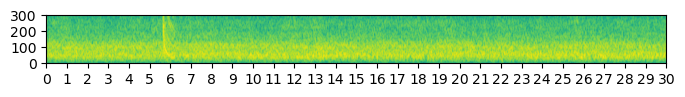

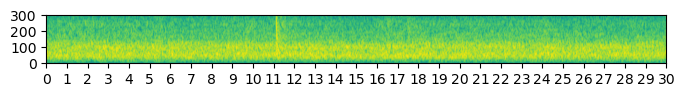

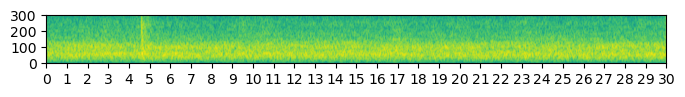

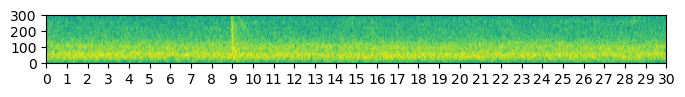

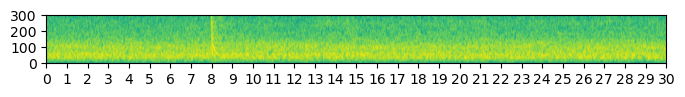

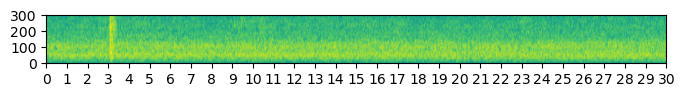

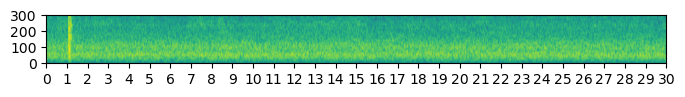

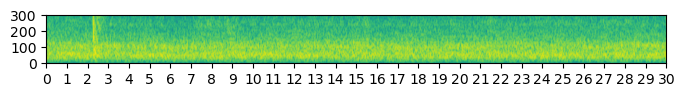

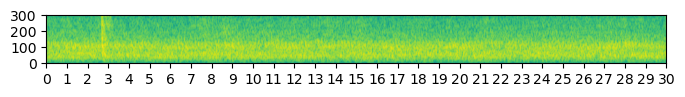

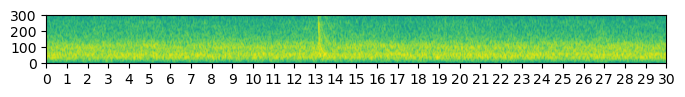

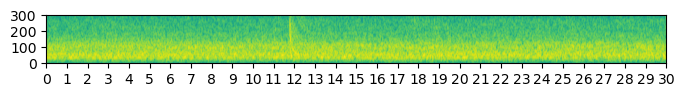

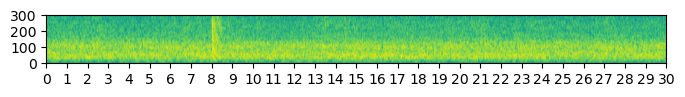

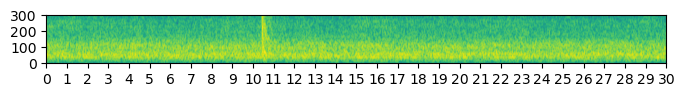

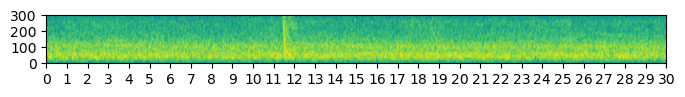

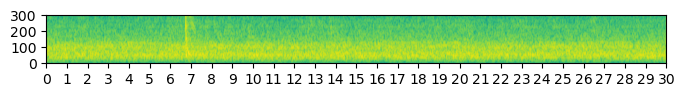

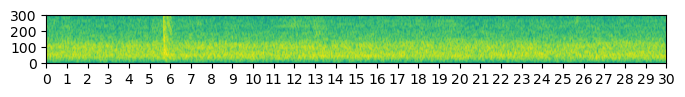

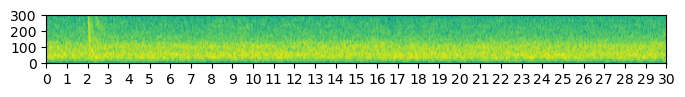

In [4]:
## Settings
chunk_size = 30
timestamp = '2022-05-23T23:39:18'

# object to read timestamp from WAV file
WR = WAVReader(sensors=config['TOSSIT']['ids'], chunk_size=chunk_size, fs_desired=config['signal']['fs'])

success, file_list, data = WR.get_audio(timestamp=np.datetime64(timestamp))
print(success)
print(data.shape)
print(file_list)

for i in range(data.shape[0]):
    fig = plt.figure()
    ax2 = fig.gca()
    spect = to_spect(data[i,...] - data[i,...].mean()).squeeze()
    ax2.imshow(spect)

    # set x ticks
    x_tick_labels = np.arange(0, chunk_size + 1, 1)
    old_range_x = [0, chunk_size]
    new_range_x = [0, spect.shape[1]]
    ax2.set_xticks([convert_range(old_range_x, new_range_x, val) for val in x_tick_labels])
    ax2.set_xticklabels([int(val) if val.is_integer() else val for val in x_tick_labels])

    # set y ticks
    y_tick_labels = np.arange(0, config['signal']['fs'] / 2 + 1, 100)
    old_range_y = [0, config['signal']['fs'] / 2]
    new_range_y = [0, spect.shape[0]]
    ax2.set_yticks([convert_range(old_range_y, new_range_y, val) for val in y_tick_labels])
    ax2.set_yticklabels(reversed([int(val) if val.is_integer() else val for val in y_tick_labels]))

## Process Data

Load Model

In [15]:
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.25).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Preprocess Data

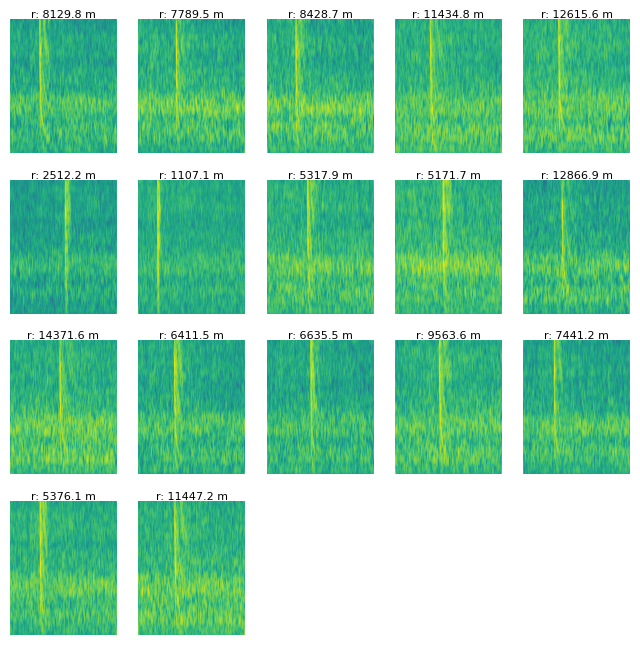

In [56]:
with h5py.File(os.path.join("/",ccb_data_root,"gunshots_44.h5"), "r") as f:
    inputs = f["/data"][:]
    sensors = f["/sensors"][:]
    true_latlon = f["/location"][:]
    
# get position and sensor ranges
xt, yt = pargs(true_latlon[1], true_latlon[0])
ranges = np.sqrt(((TOSSIT_locations - np.stack((-yt, xt), axis=1)) ** 2).sum(axis=1))

# mean center + L2 norm
inputs = inputs - inputs.mean(axis=1, keepdims=True)
inputs = inputs / np.sqrt((inputs ** 2).sum(axis=1, keepdims=True))

# convert to spectrogram and preprocess
inputs = torch.from_numpy(to_spect(inputs).copy()).float()
inputs = transform(inputs).squeeze()

# display data
rows = int(np.floor(np.sqrt(inputs.shape[0])));
columns = int(np.ceil(inputs.shape[0]/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= inputs.shape[0]:
            fig.delaxes(ax2)
        else:
            ax2.imshow(inputs[c,...], aspect='auto')
            ax2.axis('off')
            ax2.set_title(f"r: {np.around(ranges[c], 1)} m",fontsize=8, y=0.95)
        c += 1

### Localization

In [49]:
def localize(r_p, sensors_idx):
    
    # TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

loc = localize(np.asarray(ranges), np.asarray([0, 1, 2, 3]))

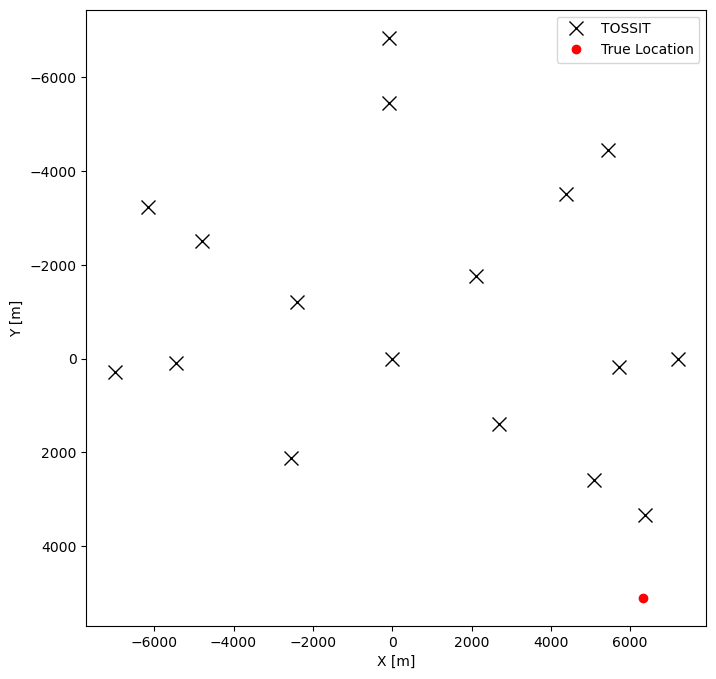

In [55]:
include_predictions = False

# plot TOSSITs
plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")

# plot predicted and true location with range circles
if include_predictions:
    for idx, r in enumerate(ranges):
        x, y = circle(r, TOSSIT_locations[idx,1], TOSSIT_locations[idx,0])
        plt.plot(x, y, '-b')
        plt.plot(loc[1], loc[0], 'ro', label="Location Estimate")

xt, yt = pargs(true_latlon[1], true_latlon[0])
plt.plot(xt, yt, 'ro', label="True Location")
    
# labels
plt.gca().invert_yaxis()
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()